In [ ]:
!pip install scikit-learn==1.4.0

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# EDA

In [ ]:
!git clone https://github.com/smahmood-data/GroupB_AI4ALL.git
%cd GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model
!pip install -r requirements.txt

fatal: destination path 'GroupB_AI4ALL' already exists and is not an empty directory.
/content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.0 MB/s eta 0:00:00


In [ ]:
# Get data / applying cleaning rules
!python src/continuous_pipeline.py weekly

Puerto Rico official cases: 385 complete weeks, latest 2026-05-18.
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.9.0 when using version 1.4.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Traceback (most recent call last):
  File "/content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/src/continuous_pipeline.py", line 285, in <module>
    main()
  File "/content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/src/continuous_pipeline.py", line 251, in main
    predictions, metrics = predict_and_monitor(config, as_of, args.refresh)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/src/continuous_pipeline.py", line 180, in predic

In [ ]:
import subprocess
result = subprocess.run(['python', 'src/continuous_pipeline.py', 'weekly'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Puerto Rico official cases: 385 complete weeks, latest 2026-05-18.

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.9.0 when using version 1.4.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Traceback (most recent call last):
  File "/content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/src/continuous_pipeline.py", line 285, in <module>
    main()
  File "/content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/src/continuous_pipeline.py", line 251, in main
    predictions, metrics = predict_and_monitor(config, as_of, args.refresh)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/src/continuous_pipeline.py", line 180, in predi

## Overview of case data

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_cases = pd.read_csv('data/operational/cases/pr_weekly.csv')
print("--- Case Data Overview ---")
display(df_cases.info())
display(df_cases.head())

--- Case Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385 entries, 0 to 384
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   geography                385 non-null    object
 1   week_start_date          385 non-null    object
 2   total_cases              385 non-null    int64 
 3   pcr_cases                385 non-null    int64 
 4   igm_cases                385 non-null    int64 
 5   hospitalized_cases       385 non-null    int64 
 6   complete_week            385 non-null    bool  
 7   source_file_id           385 non-null    object
 8   source_publication_date  385 non-null    object
 9   retrieved_at_utc         385 non-null    object
 10  source_page              385 non-null    object
dtypes: bool(1), int64(4), object(6)
memory usage: 30.6+ KB


None

,geography,week_start_date,total_cases,pcr_cases,igm_cases,hospitalized_cases,complete_week,source_file_id,source_publication_date,retrieved_at_utc,source_page
0,pr,2019-01-07,1,1,0,1,True,2450f009-9079-4bdb-8799-1600bdd4fce1,2026-06-04T15:56:55.527867Z,2026-07-18T15:41:28.688988+00:00,https://datos.salud.pr.gov
1,pr,2019-01-14,1,0,1,0,True,2450f009-9079-4bdb-8799-1600bdd4fce1,2026-06-04T15:56:55.527867Z,2026-07-18T15:41:28.688988+00:00,https://datos.salud.pr.gov
2,pr,2019-01-21,1,0,1,0,True,2450f009-9079-4bdb-8799-1600bdd4fce1,2026-06-04T15:56:55.527867Z,2026-07-18T15:41:28.688988+00:00,https://datos.salud.pr.gov
3,pr,2019-01-28,0,0,0,0,True,2450f009-9079-4bdb-8799-1600bdd4fce1,2026-06-04T15:56:55.527867Z,2026-07-18T15:41:28.688988+00:00,https://datos.salud.pr.gov
4,pr,2019-02-04,0,0,0,0,True,2450f009-9079-4bdb-8799-1600bdd4fce1,2026-06-04T15:56:55.527867Z,2026-07-18T15:41:28.688988+00:00,https://datos.salud.pr.gov


**Missing Value Check**

In [ ]:
print("--- Missing Values ---")
print(df_cases.isnull().sum())

--- Missing Values ---
geography                  0
week_start_date            0
total_cases                0
pcr_cases                  0
igm_cases                  0
hospitalized_cases         0
complete_week              0
source_file_id             0
source_publication_date    0
retrieved_at_utc           0
source_page                0
dtype: int64


~ No missing values in case data

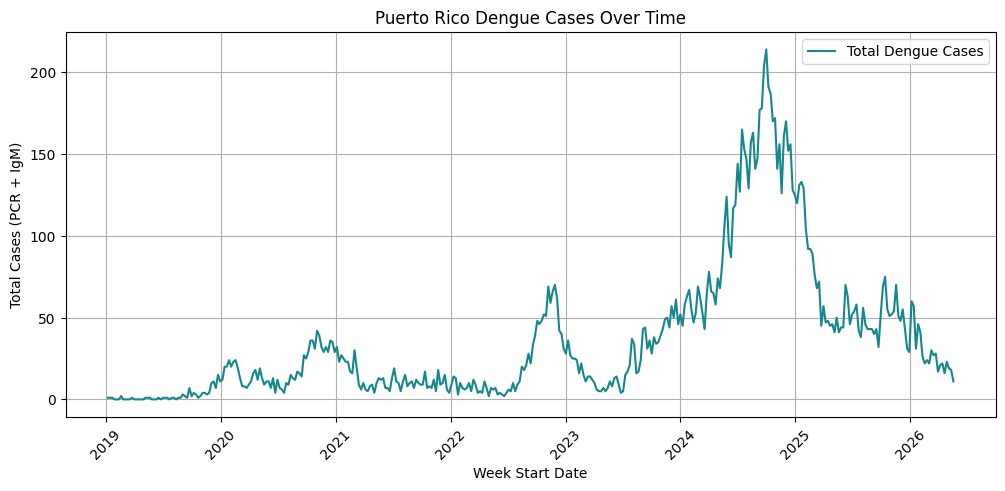

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(df_cases['week_start_date']), df_cases['total_cases'], color='#14888C', label='Total Dengue Cases')
plt.title('Puerto Rico Dengue Cases Over Time')
plt.xlabel('Week Start Date')
plt.ylabel('Total Cases (PCR + IgM)')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
df_preds = pd.read_csv('data/operational/predictions.csv')
print(df_preds.columns.tolist())
df_preds.head()

['geography', 'geography_name', 'generated_at_utc', 'as_of_date', 'week_start_date', 'lead_weeks', 'time_scope', 'model_version', 'model_variant', 'predicted_cases_p50', 'predicted_cases_p80', 'predicted_cases_p90', 'case_forecast_reliability', 'case_risk_level', 'p50_above_threshold', 'p80_above_threshold', 'p90_above_threshold', 'held_out_case_mae', 'held_out_normal_week_mae', 'held_out_outbreak_week_mae', 'outbreak_probability', 'alert_gate', 'outbreak_alert', 'historical_outbreak_threshold_cases', 'outbreak_definition', 'held_out_precision', 'held_out_recall', 'held_out_f1', 'held_out_pr_auc', 'held_out_brier', 'training_data_cutoff', 'case_source_publication_date', 'latest_case_week', 'case_data_age_weeks', 'case_report_anchor_week', 'case_report_age_weeks', 'weather_days_available', 'forecast_input_days', 'weather_sources', 'actual_cases', 'absolute_case_error', 'actual_outbreak', 'evaluated_at_utc']


,geography,geography_name,generated_at_utc,as_of_date,week_start_date,lead_weeks,time_scope,model_version,model_variant,predicted_cases_p50,...,case_data_age_weeks,case_report_anchor_week,case_report_age_weeks,weather_days_available,forecast_input_days,weather_sources,actual_cases,absolute_case_error,actual_outbreak,evaluated_at_utc
0,pr,Puerto Rico,2026-07-15T04:14:36.140902+00:00,2026-07-15,2026-07-13,0,current_week,pr-dc00d998e3fd,weather_only,NaN,...,8.0,NaN,NaN,7,4,open_meteo_live:arecibo+open_meteo_live:caguas...,NaN,NaN,NaN,NaN
1,pr,Puerto Rico,2026-07-18T10:03:23.026898+00:00,2026-07-15,2026-07-13,0,current_week,pr-a13c7f62f242,weather_only,6.346737,...,8.0,NaN,NaN,7,4,open_meteo_live:arecibo+open_meteo_live:caguas...,NaN,NaN,NaN,NaN
2,pr,Puerto Rico,2026-07-15T04:14:36.140902+00:00,2026-07-15,2026-07-20,1,forecast_week,pr-dc00d998e3fd,weather_only,NaN,...,9.0,NaN,NaN,7,7,open_meteo_live:arecibo+open_meteo_live:caguas...,NaN,NaN,NaN,NaN
3,pr,Puerto Rico,2026-07-18T10:03:23.026898+00:00,2026-07-15,2026-07-20,1,forecast_week,pr-a13c7f62f242,weather_only,8.115503,...,9.0,NaN,NaN,7,7,open_meteo_live:arecibo+open_meteo_live:caguas...,NaN,NaN,NaN,NaN
4,pr,Puerto Rico,2026-07-18T15:42:41.216343+00:00,2026-07-18,2026-07-13,0,current_week,pr-4ffb0c3793be,weather_plus_delayed_cases,5.772658,...,8.0,2026-05-18,8.0,7,1,open_meteo_live:arecibo+open_meteo_live:caguas...,NaN,NaN,NaN,NaN


In [ ]:
df_preds[['week_start_date', 'model_version', 'model_variant', 'held_out_case_mae',
          'held_out_normal_week_mae', 'held_out_outbreak_week_mae', 'actual_cases',
          'absolute_case_error']].dropna(subset=['actual_cases'])

,week_start_date,model_version,model_variant,held_out_case_mae,held_out_normal_week_mae,held_out_outbreak_week_mae,actual_cases,absolute_case_error


~ live monitoring; no entries makes sense

In [ ]:
!grep -n "^def " /content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/src/puerto_rico_operational.py

204:def load_operations_config(path: Path) -> dict[str, Any]:
210:def load_official_cases(path: Path, geography: str = "pr") -> pd.DataFrame:
236:def finalized_cases(cases: pd.DataFrame, as_of: date, stabilization_weeks: int) -> pd.DataFrame:
246:def add_historical_health_features(cases: pd.DataFrame) -> pd.DataFrame:
276:def add_delayed_health_features(
339:def live_exact_health_features(
370:def live_delayed_health_features(
430:def _point_config(point: dict[str, Any], timezone_name: str) -> CityConfig:
442:def _weather_parameters(
464:def spatially_aggregate_daily_weather(
504:def fetch_island_training_weather(
539:def fetch_island_live_weather(
595:def _case_forecaster_to_payload(bundle: CaseForecastBundle) -> dict[str, Any]:
609:def _case_forecaster_from_payload(payload: dict[str, Any]) -> CaseForecastBundle:
631:def _fit_quantile_regressor(quantile: float) -> HistGradientBoostingRegressor:
645:def _case_forecast_metrics(
687:def _calibrate_residual_scales(
747:def _calibrate_uppe

~ Will use island training weather (based on cleaning rules notes)

~ add_historical_health_features: Nathan's noted "delayed case history"

## Pulling Weather Data (Cleaning Rules Applied)

In [ ]:
import sys
sys.path.insert(0, '/content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/src')
from puerto_rico_operational import fetch_island_training_weather, load_operations_config
from pathlib import Path

config = load_operations_config(Path('/content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/config/operations.json'))

weather_weekly, source_states = fetch_island_training_weather(
    cases=df_cases,
    config=config,
    cache_dir=Path('/content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/.cache'),
    refresh=False,
)
print(source_states)
weather_weekly.head()

fresh_cache+live_api


,week_start_date,weather_days_available,weather_sources,forecast_input_days,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,relative_humidity_2m_mean,dew_point_2m_mean,soil_moisture_0_to_7cm_mean,et0_fao_evapotranspiration,wet_day_count,heavy_rain_day_count,max_daily_rainfall,longest_dry_spell_days
0,2019-01-07,7,open_meteo_archive:arecibo+open_meteo_archive:...,0,23.442857,29.1,18.1,13.783333,13.783333,51.500000,78.309524,19.240476,0.264786,22.418333,7.0,0.0,2.733333,0.0
1,2019-01-14,7,open_meteo_archive:arecibo+open_meteo_archive:...,0,23.202381,29.1,16.7,8.966667,8.966667,34.666667,76.261905,18.528571,0.257167,24.000000,7.0,0.0,3.366667,0.0
2,2019-01-21,7,open_meteo_archive:arecibo+open_meteo_archive:...,0,23.359524,29.7,16.4,14.050000,14.050000,59.833333,77.761905,19.042857,0.269833,22.943333,7.0,0.0,3.900000,0.0
3,2019-01-28,7,open_meteo_archive:arecibo+open_meteo_archive:...,0,23.611905,29.8,17.7,9.866667,9.866667,27.833333,75.000000,18.626190,0.248071,25.525000,7.0,0.0,3.950000,0.0
4,2019-02-04,7,open_meteo_archive:arecibo+open_meteo_archive:...,0,23.669048,29.6,18.2,18.250000,18.250000,69.500000,79.047619,19.585714,0.260833,24.356667,7.0,0.0,3.400000,0.0


**Missing value check for weather data**

In [ ]:
# --- Missing Values ---
print("--- Missing Values ---")
print(weather_weekly.isnull().sum())

# --- Weekly completeness check ---
print("\n--- Weather Days Available per Week ---")
print(weather_weekly['weather_days_available'].value_counts())

# --- Missing weeks in the sequence ---
full_range = pd.date_range(
    weather_weekly['week_start_date'].min(),
    weather_weekly['week_start_date'].max(),
    freq='W-MON'
)
missing_weeks = full_range.difference(weather_weekly['week_start_date'])
print(f"\n--- Missing Weeks ---")
print(f"Missing weeks: {len(missing_weeks)}")
print(missing_weeks)

# --- Date range comparison vs case data ---
print("\n--- Date Range Comparison ---")
print("Case data range:", df_cases['week_start_date'].min(), "to", df_cases['week_start_date'].max())
print("Weather data range:", weather_weekly['week_start_date'].min(), "to", weather_weekly['week_start_date'].max())

--- Missing Values ---
week_start_date                0
weather_days_available         0
weather_sources                0
forecast_input_days            0
temperature_2m_mean            0
temperature_2m_max             0
temperature_2m_min             0
precipitation_sum              0
rain_sum                       0
precipitation_hours            0
relative_humidity_2m_mean      0
dew_point_2m_mean              0
soil_moisture_0_to_7cm_mean    0
et0_fao_evapotranspiration     0
wet_day_count                  0
heavy_rain_day_count           0
max_daily_rainfall             0
longest_dry_spell_days         0
dtype: int64

--- Weather Days Available per Week ---
weather_days_available
7    385
Name: count, dtype: int64

--- Missing Weeks ---
Missing weeks: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='W-MON')

--- Date Range Comparison ---
Case data range: 2019-01-07 to 2026-05-18
Weather data range: 2019-01-07 00:00:00 to 2026-05-18 00:00:00


~ No missing values

**Merging case and weather data**

In [ ]:
df_cases['week_start_date'] = pd.to_datetime(df_cases['week_start_date'])
weather_weekly['week_start_date'] = pd.to_datetime(weather_weekly['week_start_date'])

df_merged = pd.merge(df_cases, weather_weekly, on='week_start_date', how='inner')
print(df_merged.shape)
df_merged.head()

(385, 28)


,geography,week_start_date,total_cases,pcr_cases,igm_cases,hospitalized_cases,complete_week,source_file_id,source_publication_date,retrieved_at_utc,...,rain_sum,precipitation_hours,relative_humidity_2m_mean,dew_point_2m_mean,soil_moisture_0_to_7cm_mean,et0_fao_evapotranspiration,wet_day_count,heavy_rain_day_count,max_daily_rainfall,longest_dry_spell_days
0,pr,2019-01-07,1,1,0,1,True,2450f009-9079-4bdb-8799-1600bdd4fce1,2026-06-04T15:56:55.527867Z,2026-07-18T15:41:28.688988+00:00,...,13.783333,51.500000,78.309524,19.240476,0.264786,22.418333,7.0,0.0,2.733333,0.0
1,pr,2019-01-14,1,0,1,0,True,2450f009-9079-4bdb-8799-1600bdd4fce1,2026-06-04T15:56:55.527867Z,2026-07-18T15:41:28.688988+00:00,...,8.966667,34.666667,76.261905,18.528571,0.257167,24.000000,7.0,0.0,3.366667,0.0
2,pr,2019-01-21,1,0,1,0,True,2450f009-9079-4bdb-8799-1600bdd4fce1,2026-06-04T15:56:55.527867Z,2026-07-18T15:41:28.688988+00:00,...,14.050000,59.833333,77.761905,19.042857,0.269833,22.943333,7.0,0.0,3.900000,0.0
3,pr,2019-01-28,0,0,0,0,True,2450f009-9079-4bdb-8799-1600bdd4fce1,2026-06-04T15:56:55.527867Z,2026-07-18T15:41:28.688988+00:00,...,9.866667,27.833333,75.000000,18.626190,0.248071,25.525000,7.0,0.0,3.950000,0.0
4,pr,2019-02-04,0,0,0,0,True,2450f009-9079-4bdb-8799-1600bdd4fce1,2026-06-04T15:56:55.527867Z,2026-07-18T15:41:28.688988+00:00,...,18.250000,69.500000,79.047619,19.585714,0.260833,24.356667,7.0,0.0,3.400000,0.0


### Lag correlation analysis

In [ ]:
import numpy as np

weather_cols = ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min',
                 'precipitation_sum', 'rain_sum', 'precipitation_hours',
                 'relative_humidity_2m_mean', 'dew_point_2m_mean',
                 'soil_moisture_0_to_7cm_mean', 'et0_fao_evapotranspiration',
                 'wet_day_count', 'heavy_rain_day_count', 'max_daily_rainfall',
                 'longest_dry_spell_days']

lags = range(0, 9)  # 0 to 8 weeks
lag_corr = pd.DataFrame(index=lags, columns=weather_cols, dtype=float)

for col in weather_cols:
    for lag in lags:
        lag_corr.loc[lag, col] = df_merged['total_cases'].corr(df_merged[col].shift(lag))

lag_corr

,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,relative_humidity_2m_mean,dew_point_2m_mean,soil_moisture_0_to_7cm_mean,et0_fao_evapotranspiration,wet_day_count,heavy_rain_day_count,max_daily_rainfall,longest_dry_spell_days
0,0.166448,0.055327,0.266097,0.115779,0.115779,-0.053231,0.231021,0.247417,-0.102751,-0.176500,0.048150,0.110341,0.066769,-0.040993
1,0.197159,0.077516,0.287079,0.107404,0.107404,-0.063825,0.229742,0.271128,-0.094997,-0.150742,0.048461,0.105354,0.067889,-0.041913
2,0.213634,0.086477,0.307825,0.138892,0.138892,-0.041118,0.262738,0.298998,-0.059021,-0.151258,0.054422,0.128918,0.088003,-0.046750
3,0.232365,0.096958,0.338412,0.164226,0.164226,-0.016900,0.292977,0.327622,-0.022186,-0.148476,0.063076,0.162125,0.103140,-0.054211
4,0.246406,0.108553,0.359543,0.201973,0.201973,0.013661,0.316067,0.349264,-0.001039,-0.145694,0.076594,0.189309,0.128832,-0.070283
5,0.270768,0.131943,0.381429,0.207854,0.207854,0.018319,0.300721,0.361703,-0.001232,-0.111909,0.060776,0.181003,0.138734,-0.051021
6,0.294445,0.155509,0.403407,0.216575,0.216575,0.020033,0.310140,0.384054,0.000495,-0.086127,0.087093,0.198464,0.147141,-0.079184
7,0.321399,0.187043,0.415016,0.213366,0.213366,0.011975,0.294548,0.398326,-0.007992,-0.048745,0.085482,0.192357,0.158175,-0.077832
8,0.333519,0.200297,0.422570,0.215714,0.215714,0.010370,0.291767,0.406598,-0.003838,-0.025850,0.073546,0.186641,0.162084,-0.063484


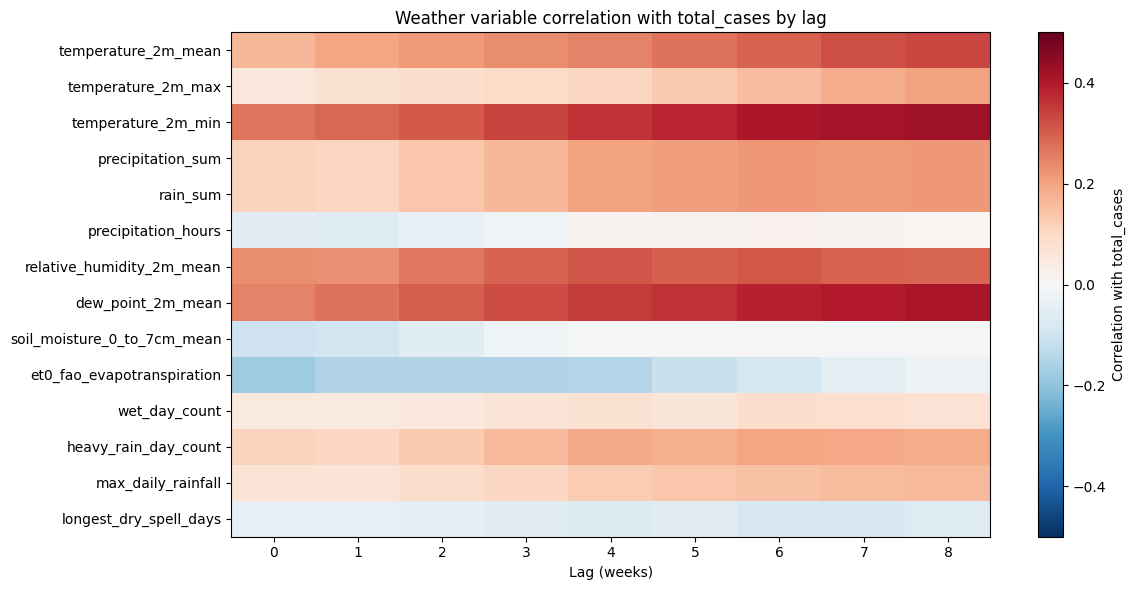

In [ ]:
# Quick heatmap viz of previous output
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.imshow(lag_corr.T.astype(float), aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
plt.colorbar(label='Correlation with total_cases')
plt.yticks(range(len(weather_cols)), weather_cols)
plt.xticks(range(len(lags)), lags)
plt.xlabel('Lag (weeks)')
plt.title('Weather variable correlation with total_cases by lag')
plt.tight_layout()
plt.show()

In [ ]:
# List of top correlations
best = lag_corr.abs().max().sort_values(ascending=False)
best_lags = lag_corr.abs().idxmax()
summary = pd.DataFrame({'best_abs_corr': best, 'best_lag': best_lags})
summary

,best_abs_corr,best_lag
dew_point_2m_mean,0.406598,8
et0_fao_evapotranspiration,0.176500,0
heavy_rain_day_count,0.198464,6
longest_dry_spell_days,0.079184,6
max_daily_rainfall,0.162084,8
precipitation_hours,0.063825,1
precipitation_sum,0.216575,6
rain_sum,0.216575,6
relative_humidity_2m_mean,0.316067,4
soil_moisture_0_to_7cm_mean,0.102751,0


**Reading correlation in relation to the context of Dengue fever**

[1]

~ Temperature (0.42) and dew point (0.41) show the strongest correlations, then relative humidity (0.32) and mean temperature (0.33)

~ Makes sense considering context (dengue biology): warmer / more humid = faster mosquito development and disease spreading

[2]

~ Mosquito breeding cycle is dependent on precipitation (rain -> still water -> larvae -> adult mosquitoes after several weeks)

~ Precipitation-related variables (precipitation_sum, rain_sum, heavy_rain_day_count, max_daily_rainfall) = weaker but consistent positive correlation (~0.16–0.22); peak around lag 6

[3]

~ soil_moisture, wet_day_count, longest_dry_spell_days are weak (<0.1); not worth prioritizing as features

[!]

~ This doesn't show us peak for temperature and dew point (correlation keeps rising up to lag 8) so it could be higher than 8


In [ ]:
# Rerunning with wider lag range and prioritized features only
priority_cols = [
    'relative_humidity_2m_mean',
    'precipitation_hours',
    'temperature_2m_min',
    'temperature_2m_mean',
    'dew_point_2m_mean',
]

lags = range(0, 21)
lag_corr = pd.DataFrame(index=lags, columns=priority_cols, dtype=float)
for col in priority_cols:
    for lag in lags:
        lag_corr.loc[lag, col] = df_merged['total_cases'].corr(df_merged[col].shift(lag))

lag_corr

,relative_humidity_2m_mean,precipitation_hours,temperature_2m_min,temperature_2m_mean,dew_point_2m_mean
0,0.231021,-0.053231,0.266097,0.166448,0.247417
1,0.229742,-0.063825,0.287079,0.197159,0.271128
2,0.262738,-0.041118,0.307825,0.213634,0.298998
3,0.292977,-0.016900,0.338412,0.232365,0.327622
4,0.316067,0.013661,0.359543,0.246406,0.349264
5,0.300721,0.018319,0.381429,0.270768,0.361703
6,0.310140,0.020033,0.403407,0.294445,0.384054
7,0.294548,0.011975,0.415016,0.321399,0.398326
8,0.291767,0.010370,0.422570,0.333519,0.406598
9,0.293806,0.029055,0.435436,0.338505,0.411215


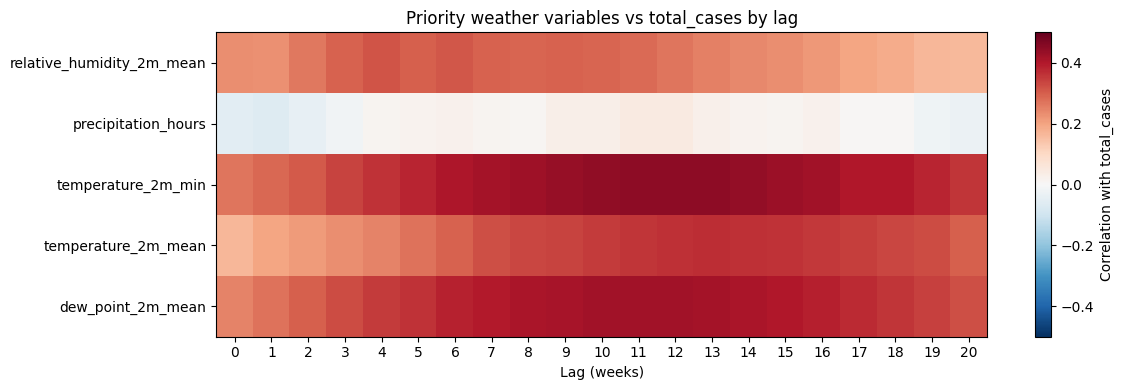

In [ ]:
import matplotlib.pyplot as plt

# Quick heatmap viz of previous output
plt.figure(figsize=(12, 4))
plt.imshow(lag_corr.T.astype(float), aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=0.5)
plt.colorbar(label='Correlation with total_cases')
plt.yticks(range(len(priority_cols)), priority_cols)
plt.xticks(range(len(lags)), lags)
plt.xlabel('Lag (weeks)')
plt.title('Priority weather variables vs total_cases by lag')
plt.tight_layout()
plt.show()

In [ ]:
# List of top correlations
best = lag_corr.abs().max().sort_values(ascending=False)
best_lags = lag_corr.abs().idxmax()
summary = pd.DataFrame({'best_abs_corr': best, 'best_lag': best_lags})
summary

,best_abs_corr,best_lag
dew_point_2m_mean,0.421586,11
precipitation_hours,0.063825,1
relative_humidity_2m_mean,0.316067,4
temperature_2m_mean,0.368465,13
temperature_2m_min,0.447254,12


**Reasonable and credible lags**

~ relative_humidity_2m_mean (lag 4, 0.32)

~ precipitation_hours (lag 1, 0.06); weak, but short lag makes sense bc rain creates breeding sites quickly, considered credible

**Not very credible lag (likely following/correlating with general seasonal patterns)**

~ dew_point_2m_mean (lag 11, 0.42)

~ temperature_2m_mean (lag 13, 0.37)

~ temperature_2m_min (lag 12, 0.45)

***IMPLICATIONS***

[A]  We want to consider lag for humidity (4-week lag) and precipitation hours (1-week lag), but NOT for seasonal features despite some high correlations (i.e. temperature and dew point, since their strongest correlation likely reflects calendar season rather than a specific weather-driven/biological mechanism of dengue).

[B]  We should of course still be considering the high correlation variables as features.

[C] *The* MAE improvement from lagged weather features (Nathan's Champion Results) occurs because XGBoost benefits from any feature with correlative strength, regardless of underlying cause. However, for temperature and dew point specifically, the lag that best correlates with cases (~12-13 weeks) is more likely following an annual seasonal pattern rather than a dengue related mechanism. So I think it is probable/possible that considering lag for these features may be emphasizing seasonality instead of any weather-driven biological effect of dengue. In addition to any potential changes to the model, this is helpful when interpreting feature importance.

In [ ]:
!grep -n "MODEL_WEATHER_COLUMNS\s*=\|WEATHER_LAGS\s*=\|CASE_FORECAST_MODEL_WEATHER_COLUMNS\s*=" /content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/src/near_realtime_outbreak_detection.py

134:OUTBREAK_MODEL_WEATHER_COLUMNS = [
143:CASE_FORECAST_MODEL_WEATHER_COLUMNS = OUTBREAK_MODEL_WEATHER_COLUMNS + [
147:MODEL_WEATHER_COLUMNS = CASE_FORECAST_MODEL_WEATHER_COLUMNS
167:WEATHER_LAGS = (0, 2, 4, 8)


***TRY***

[A] Test an addition of precipitation_hours (lag 1, 0.06) in lag consideration

[B] Don't work the temperature/dew-point lag further (?)

## Potential XGBoost Redundancy (Colinearity)

**Potential issue to look at**: If more than one variable represents the same thing (colinearity), XGBoost performance can worsen to the redundancy

In [ ]:
df_merged[['relative_humidity_2m_mean', 'dew_point_2m_mean', 'temperature_2m_mean']].corr()

,relative_humidity_2m_mean,dew_point_2m_mean,temperature_2m_mean
relative_humidity_2m_mean,1.000000,0.628470,0.206574
dew_point_2m_mean,0.628470,1.000000,0.890433
temperature_2m_mean,0.206574,0.890433,1.000000


In [ ]:
# Features used
!sed -n '107,125p' /content/GroupB_AI4ALL/2026-07-19_Nathan_Nguyen_API_Model/src/near_realtime_outbreak_detection.py

DAILY_WEATHER_COLUMNS = [
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    # Rain-only totals, rainy hours, dew point, and shallow soil moisture add
    # information about how long water remains available to mosquitoes.  These
    # names are supported by both Open-Meteo's Archive and Forecast APIs.
    "rain_sum",
    "precipitation_hours",
    "relative_humidity_2m_mean",
    "dew_point_2m_mean",
    "soil_moisture_0_to_7cm_mean",
    "et0_fao_evapotranspiration",
]

# Four weekly variables are calculated from the seven daily rain values. They
# distinguish one cloudburst, several moderate storms, and an uninterrupted
# dry spell even when weeks have similar total rainfall. ``rain_sum`` itself is


In [ ]:
df_merged['precipitation_hours_lag_0'] = df_merged['precipitation_hours']
df_merged['precipitation_hours_lag_1'] = df_merged['precipitation_hours'].shift(1)
df_merged['precipitation_hours_lag_2'] = df_merged['precipitation_hours'].shift(2)
df_merged['precipitation_hours_lag_4'] = df_merged['precipitation_hours'].shift(4)
df_merged['precipitation_hours_lag_8'] = df_merged['precipitation_hours'].shift(8)

df_merged[['precipitation_hours_lag_0', 'precipitation_hours_lag_1',
           'precipitation_hours_lag_2', 'precipitation_hours_lag_4',
           'precipitation_hours_lag_8']].corr()

,precipitation_hours_lag_0,precipitation_hours_lag_1,precipitation_hours_lag_2,precipitation_hours_lag_4,precipitation_hours_lag_8
precipitation_hours_lag_0,1.000000,0.269182,0.177184,0.143981,0.135783
precipitation_hours_lag_1,0.269182,1.000000,0.268130,0.108912,0.122122
precipitation_hours_lag_2,0.177184,0.268130,1.000000,0.181597,0.134782
precipitation_hours_lag_4,0.143981,0.108912,0.181597,1.000000,0.149934
precipitation_hours_lag_8,0.135783,0.122122,0.134782,0.149934,1.000000


In [ ]:
df_merged['humidity_lag_0'] = df_merged['relative_humidity_2m_mean']
df_merged['humidity_lag_4'] = df_merged['relative_humidity_2m_mean'].shift(4)
df_merged['humidity_lag_8'] = df_merged['relative_humidity_2m_mean'].shift(8)

df_merged[['humidity_lag_0', 'humidity_lag_4', 'humidity_lag_8']].corr()

,humidity_lag_0,humidity_lag_4,humidity_lag_8
humidity_lag_0,1.000000,0.311529,0.232574
humidity_lag_4,0.311529,1.000000,0.313769
humidity_lag_8,0.232574,0.313769,1.000000


***IMPLICATIONS***

[A] precipitation_hours lag-1 has low-collinearity and is previously untested addition to a variable the model already uses (at lags 0, 2, 4, 8); good, low-risk feature to test

[B] No collinearity concern with humidity (lag 4) relative to model's other humidity lags.

# Testing PR 2024 theory

**Potential issue to look at**: San Jan and Iquitos have relatively consistent data, but Puerto Rico's API data has a massive surge in 2024 due to outbreak in that year (smahmood-data/GroupB_AI4ALL/tree/main/2026-07-19_Nathan_Nguyen_API_Model/data/operational/cases/pr_weekly.csv); sudden outbreak may have naturally amplified absolute errors.

Saving pr_weekly.csv to pr_weekly (1).csv
      mean_weekly_cases  max_weekly_cases  total_yearly_cases  weeks_reported
year                                                                         
2019                2.0                15                 100              51
2020               18.6                42                 984              53
2021               12.2                32                 637              52
2022               20.9                70                1085              52
2023               24.8                61                1287              52
2024              115.9               214                6028              52
2025               61.8               133                3214              52
2026               28.1                60                 590              21

Overall series mean:  36.2 cases/week
2024 mean:            115.9 cases/week  (3.2x the overall average)


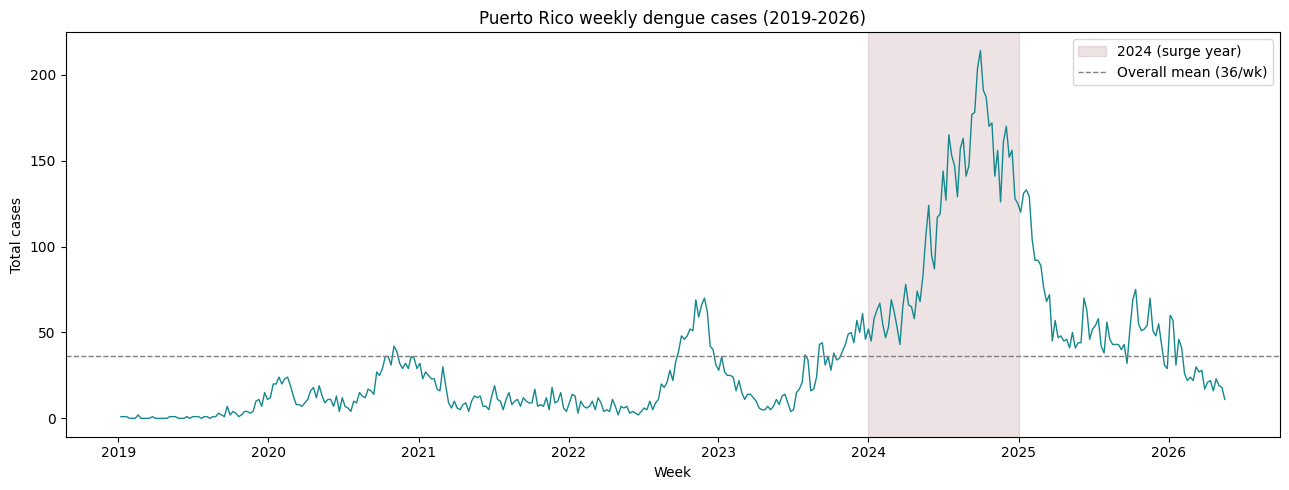

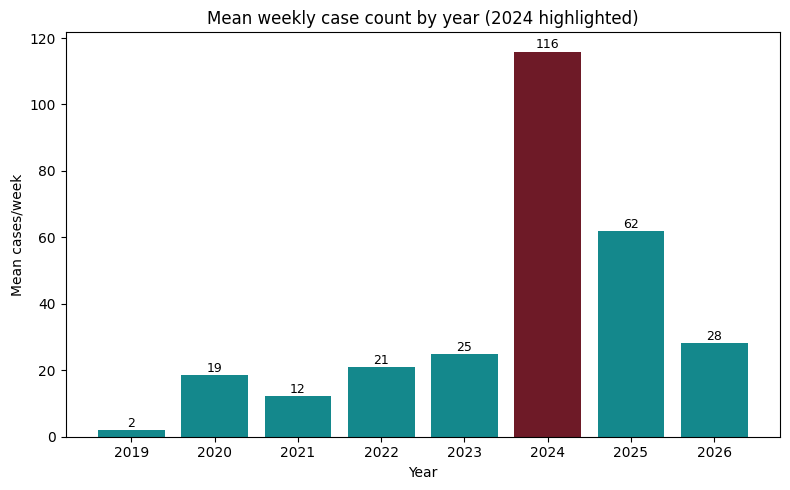

In [ ]:
# Cell 1: upload pr_weekly.csv (skip this cell if already uploaded in this session)
from google.colab import files
uploaded = files.upload()  # select pr_weekly.csv when prompted

# Cell 2: load + visualize
import pandas as pd
import matplotlib.pyplot as plt

cases = pd.read_csv("pr_weekly.csv", parse_dates=["week_start_date"])
cases = cases[cases["geography"] == "pr"].sort_values("week_start_date").reset_index(drop=True)
cases["year"] = cases["week_start_date"].dt.isocalendar().year.astype(int)

# ---- Table: yearly mean / max / total ----
yearly = cases.groupby("year")["total_cases"].agg(
    mean_weekly_cases="mean",
    max_weekly_cases="max",
    total_yearly_cases="sum",
    weeks_reported="count",
)
print(yearly.round(1).to_string())
print()
overall_mean = cases["total_cases"].mean()
surge_mean = cases.loc[cases["year"] == 2024, "total_cases"].mean()
print(f"Overall series mean:  {overall_mean:.1f} cases/week")
print(f"2024 mean:            {surge_mean:.1f} cases/week  ({surge_mean / overall_mean:.1f}x the overall average)")

# ---- Plot 1: full weekly time series, 2024 highlighted ----
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(cases["week_start_date"], cases["total_cases"], color="#14888C", linewidth=1)
ax.axvspan(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-01-01"), color="#6E1A27", alpha=0.12, label="2024 (surge year)")
ax.axhline(overall_mean, color="gray", linestyle="--", linewidth=1, label=f"Overall mean ({overall_mean:.0f}/wk)")
ax.set_title("Puerto Rico weekly dengue cases (2019-2026)")
ax.set_xlabel("Week")
ax.set_ylabel("Total cases")
ax.legend()
plt.tight_layout()
plt.savefig("pr_weekly_timeseries.png", dpi=150)
plt.show()

# ---- Plot 2: yearly mean weekly cases, bar chart ----
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#6E1A27" if yr == 2024 else "#14888C" for yr in yearly.index]
ax.bar(yearly.index.astype(str), yearly["mean_weekly_cases"], color=colors)
ax.set_title("Mean weekly case count by year (2024 highlighted)")
ax.set_ylabel("Mean cases/week")
ax.set_xlabel("Year")
for i, v in enumerate(yearly["mean_weekly_cases"]):
    ax.text(i, v + 1, f"{v:.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("pr_yearly_mean_bar.png", dpi=150)
plt.show()

Notes
* Nathan's model tested weather + case-history features
* The following model is just a quick test and does not consider weather (only uses case-history + hospitalization features exact_health)
* Test results are still significant since MAE is feature of target variable (cases); I am only trying to show that MAE inflates with sudden larger case counts

In [ ]:
# Cell 1: upload pr_weekly.csv
from google.colab import files
uploaded = files.upload()  # select pr_weekly.csv when prompted

# Cell 2 (or just continue below):
"""
Faithful reimplementation of the case-forecasting core of
src/puerto_rico_operational.py + src/dengue_forecast_model.py, testing
whether excluding the 2024-2025 surge shrinks held-out MAE.

SIMPLIFICATIONS vs. the real repo (clearly flagged, since I don't have
src/near_realtime_outbreak_detection.py, which the real pipeline imports):
  - No weather features. Only case-history + hospitalization features
    (the "exact_health" feature set) are used. This isolates the
    question we actually care about: does MAE track case-count scale,
    independent of weather.
  - add_historical_case_features() and add_expanding_outbreak_labels()
    aren't available in the files I have, so they're reimplemented here
    to match the column names/semantics implied by the rest of the code
    (CASE_FEATURE_COLUMNS, EXACT_HEALTH_FEATURE_COLUMNS).
  - min_labeled_years is a parameter (real code hardcodes 4) because the
    pre-2024 run only has ~5 calendar years total, some of which are
    needed just to seed lag/threshold history.

Everything else (CaseForecastBundle, _fit_quantile_regressor,
_calibrate_residual_scales, _calibrate_upper_offsets,
_case_forecast_metrics, fit_time_aware_case_forecaster,
add_historical_health_features, seasonal_threshold_table) is copied
verbatim or near-verbatim from the two files you shared.
"""

from __future__ import annotations
from dataclasses import dataclass
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_pinball_loss, median_absolute_error, precision_score, recall_score

CASE_QUANTILES = (0.50, 0.80, 0.90)

CASE_FEATURE_COLUMNS = ["cases_lag_1", "cases_lag_2", "cases_lag_4", "cases_mean_4", "cases_mean_8", "cases_change_1"]
HOSPITAL_FEATURE_COLUMNS = ["hospitalized_lag_1", "hospitalized_lag_2", "hospitalized_mean_4", "hospitalization_rate_mean_4"]
EXACT_HEALTH_FEATURE_COLUMNS = CASE_FEATURE_COLUMNS + HOSPITAL_FEATURE_COLUMNS


# ---- verbatim from dengue_forecast_model.py ----
def seasonal_threshold_table(train_features: pd.DataFrame, window: int = 2) -> pd.DataFrame:
    records = []
    weeks = np.arange(1, 54)
    for week in weeks:
        cyclic_distance = np.minimum(
            np.abs(train_features["weekofyear"] - week),
            53 - np.abs(train_features["weekofyear"] - week),
        )
        seasonal_cases = train_features.loc[cyclic_distance <= window, "total_cases"]
        if len(seasonal_cases) == 0:
            q60 = train_features["total_cases"].quantile(0.60)
            q75 = train_features["total_cases"].quantile(0.75)
        else:
            q60 = seasonal_cases.quantile(0.60)
            q75 = seasonal_cases.quantile(0.75)
        records.append({"weekofyear": week, "near_outbreak_threshold": q60, "outbreak_threshold": q75})
    return pd.DataFrame(records)


# ---- reimplemented (source file not available) ----
def add_historical_case_features(cases: pd.DataFrame) -> pd.DataFrame:
    frame = cases.sort_values("week_start_date").copy()
    frame["cases_lag_1"] = frame["total_cases"].astype(float).shift(1)
    frame["cases_lag_2"] = frame["total_cases"].astype(float).shift(2)
    frame["cases_lag_4"] = frame["total_cases"].astype(float).shift(4)
    prior = frame["total_cases"].astype(float).shift(1)
    frame["cases_mean_4"] = prior.rolling(4, min_periods=4).mean()
    frame["cases_mean_8"] = prior.rolling(8, min_periods=8).mean()
    frame["cases_change_1"] = frame["cases_lag_1"] - frame["cases_lag_2"]
    return frame


# ---- verbatim from puerto_rico_operational.py ----
def add_historical_health_features(cases: pd.DataFrame) -> pd.DataFrame:
    frame = add_historical_case_features(cases)
    hospitalized = frame["hospitalized_cases"].astype(float)
    cases_shifted = frame["total_cases"].astype(float).shift(1)
    hospitalized_shifted = hospitalized.shift(1)
    frame["hospitalized_lag_1"] = hospitalized.shift(1)
    frame["hospitalized_lag_2"] = hospitalized.shift(2)
    frame["hospitalized_mean_4"] = hospitalized_shifted.rolling(4, min_periods=4).mean()
    case_sum_4 = cases_shifted.rolling(4, min_periods=4).sum()
    hospital_sum_4 = hospitalized_shifted.rolling(4, min_periods=4).sum()
    frame["hospitalization_rate_mean_4"] = hospital_sum_4 / case_sum_4.replace(0, np.nan)
    frame.loc[(case_sum_4 == 0) & (hospital_sum_4 == 0), "hospitalization_rate_mean_4"] = 0.0
    return frame


# ---- reimplemented (source file not available) ----
def add_expanding_outbreak_labels(cases: pd.DataFrame, min_prior_years: int = 2) -> pd.DataFrame:
    cases = cases.sort_values("week_start_date").copy()
    years = sorted(cases["year"].unique())
    parts = []
    for yr in years:
        prior = cases[cases["year"] < yr]
        if prior["year"].nunique() < min_prior_years:
            continue
        thresholds = seasonal_threshold_table(prior)[["weekofyear", "outbreak_threshold"]]
        yr_rows = cases[cases["year"] == yr].merge(thresholds, on="weekofyear", how="left")
        yr_rows["outbreak_label"] = (yr_rows["total_cases"] >= yr_rows["outbreak_threshold"]).astype(int)
        parts.append(yr_rows)
    if not parts:
        return cases.assign(outbreak_threshold=np.nan, outbreak_label=np.nan)
    return pd.concat(parts, ignore_index=True).sort_values("week_start_date")


# ---- verbatim from puerto_rico_operational.py ----
def _fit_quantile_regressor(quantile: float) -> HistGradientBoostingRegressor:
    return HistGradientBoostingRegressor(
        loss="quantile", quantile=quantile, learning_rate=0.05, max_iter=90,
        max_leaf_nodes=16, l2_regularization=0.05, random_state=42,
    )


def _case_forecast_metrics(predictions: pd.DataFrame, persistence_column: str = "cases_lag_1"):
    actual = predictions["actual_cases"].astype(float)
    p50 = predictions["predicted_cases_p50"].astype(float)
    p80 = predictions["predicted_cases_p80"].astype(float)
    p90 = predictions["predicted_cases_p90"].astype(float)
    outbreak = predictions["actual_outbreak"].astype(int)
    threshold_signal = p50 >= predictions["outbreak_threshold"].astype(float)
    normal = outbreak == 0
    elevated = outbreak == 1
    return {
        "held_out_rows": float(len(predictions)),
        "mae": float(mean_absolute_error(actual, p50)),
        "median_absolute_error": float(median_absolute_error(actual, p50)),
        "normal_week_mae": float(mean_absolute_error(actual[normal], p50[normal])) if normal.any() else None,
        "outbreak_week_mae": float(mean_absolute_error(actual[elevated], p50[elevated])) if elevated.any() else None,
        "p80_pinball_loss": float(mean_pinball_loss(actual, p80, alpha=0.80)),
        "p90_pinball_loss": float(mean_pinball_loss(actual, p90, alpha=0.90)),
        "p80_coverage": float((actual <= p80).mean()),
        "p90_coverage": float((actual <= p90).mean()),
        "p50_threshold_precision": float(precision_score(outbreak, threshold_signal, zero_division=0)),
        "p50_threshold_recall": float(recall_score(outbreak, threshold_signal, zero_division=0)),
        "persistence_mae": float(mean_absolute_error(actual, predictions[persistence_column].astype(float))),
    }


def _calibrate_residual_scales(available_training, feature_columns, baseline_column, validation_filter):
    years = sorted(available_training["year"].astype(int).unique())
    if len(years) < 3:
        return {q: 1.0 for q in CASE_QUANTILES}
    calibration_year = years[-1]
    inner_train = available_training[available_training["year"] < calibration_year].copy()
    calibration = available_training[available_training["year"] == calibration_year].copy()
    if len(inner_train) < 100 or calibration.empty:
        return {q: 1.0 for q in CASE_QUANTILES}
    target = inner_train["total_cases"].astype(float) - inner_train[baseline_column].astype(float)
    calibration_actual = calibration["total_cases"].astype(float).to_numpy()
    calibration_baseline = calibration[baseline_column].astype(float).to_numpy()
    candidates = np.linspace(0.0, 1.5, 31)
    scales = {}
    for quantile in CASE_QUANTILES:
        model = _fit_quantile_regressor(quantile)
        model.fit(inner_train[feature_columns], target)
        residual = model.predict(calibration[feature_columns])
        scores = []
        for scale in candidates:
            prediction = np.maximum(0.0, calibration_baseline + scale * residual)
            loss = mean_absolute_error(calibration_actual, prediction) if quantile == 0.50 else mean_pinball_loss(calibration_actual, prediction, alpha=quantile)
            scores.append((float(loss), float(scale)))
        scales[quantile] = min(scores, key=lambda item: (item[0], item[1]))[1]
    return scales


def _calibrate_upper_offsets(available_training, feature_columns, baseline_column, validation_filter, residual_scales):
    years = sorted(available_training["year"].astype(int).unique())
    if len(years) < 3:
        return {0.80: 0.0, 0.90: 0.0}
    calibration_years = years[-min(3, len(years) - 2):]
    errors = []
    for calibration_year in calibration_years:
        inner_train = available_training[available_training["year"] < calibration_year].copy()
        calibration = available_training[available_training["year"] == calibration_year].copy()
        if len(inner_train) < 100 or calibration.empty:
            continue
        train_target = inner_train["total_cases"].astype(float)
        if baseline_column is not None:
            train_target = train_target - inner_train[baseline_column].astype(float)
            calibration_baseline = calibration[baseline_column].astype(float).to_numpy()
        else:
            calibration_baseline = np.zeros(len(calibration), dtype=float)
        median_model = _fit_quantile_regressor(0.50)
        median_model.fit(inner_train[feature_columns], train_target)
        median_prediction = np.maximum(0.0, calibration_baseline + residual_scales.get(0.50, 1.0) * median_model.predict(calibration[feature_columns]))
        errors.append(calibration["total_cases"].astype(float).to_numpy() - median_prediction)
    if not errors:
        return {0.80: 0.0, 0.90: 0.0}
    upper_error = np.concatenate(errors)
    return {q: max(0.0, float(np.quantile(upper_error, q))) for q in (0.80, 0.90)}


@dataclass
class CaseForecastBundle:
    models: dict
    feature_columns: list
    validation_metrics: dict
    validation_predictions: list
    baseline_column: str | None = None
    residual_scales: dict | None = None
    upper_offsets: dict | None = None


def fit_time_aware_case_forecaster(
    training_frame, feature_columns, variant, baseline_column=None,
    n_validation_years=4, validation_filter=None, fallback_to_persistence=False,
    min_labeled_years=4,
):
    frame = training_frame.sort_values("week_start_date").copy()
    frame = frame.dropna(subset=feature_columns + ["total_cases"])
    labeled_years = sorted(frame.loc[frame["outbreak_label"].notna(), "year"].astype(int).unique())
    if len(labeled_years) < min_labeled_years:
        raise ValueError(f"At least {min_labeled_years} labeled years are required (have {len(labeled_years)}: {labeled_years})")
    validation_years = labeled_years[-min(n_validation_years, len(labeled_years) - 2):]
    held_out_parts = []

    for validation_year in validation_years:
        train = frame[frame["year"] < validation_year]
        validation = frame[(frame["year"] == validation_year) & frame["outbreak_label"].notna()].copy()
        if len(train) < 100 or validation.empty:
            continue

        fold_predictions = []
        train_target = train["total_cases"].astype(float)
        fold_scales = {q: 1.0 for q in CASE_QUANTILES}
        if baseline_column is not None:
            train_target = train_target - train[baseline_column].astype(float)
            fold_scales = _calibrate_residual_scales(train, feature_columns, baseline_column, validation_filter)
        fold_upper_offsets = _calibrate_upper_offsets(train, feature_columns, baseline_column, validation_filter, fold_scales)

        for quantile in CASE_QUANTILES:
            model = _fit_quantile_regressor(quantile)
            model.fit(train[feature_columns], train_target)
            validation_baseline = validation[baseline_column].astype(float).to_numpy() if baseline_column is not None else 0.0
            fold_predictions.append(np.maximum(0.0, validation_baseline + fold_scales[quantile] * model.predict(validation[feature_columns])))

        ordered = np.maximum.accumulate(np.column_stack(fold_predictions), axis=1)
        ordered[:, 1] = np.maximum(ordered[:, 1], ordered[:, 0] + fold_upper_offsets[0.80])
        ordered[:, 2] = np.maximum(ordered[:, 2], ordered[:, 0] + fold_upper_offsets[0.90])
        validation["predicted_cases_p50"] = ordered[:, 0]
        validation["predicted_cases_p80"] = ordered[:, 1]
        validation["predicted_cases_p90"] = ordered[:, 2]
        validation["actual_cases"] = validation["total_cases"].astype(float)
        validation["actual_outbreak"] = validation["outbreak_label"].astype(int)
        validation["outbreak_threshold"] = validation["outbreak_threshold"].astype(float)
        validation["forecast_variant"] = variant
        held_out_parts.append(validation)

    if not held_out_parts:
        raise ValueError("Unable to create time-held-out case-count predictions")
    held_out = pd.concat(held_out_parts, ignore_index=True).sort_values("week_start_date")
    persistence_column = baseline_column or "cases_lag_1"
    used_persistence_fallback = False
    if fallback_to_persistence and baseline_column is not None:
        model_mae = mean_absolute_error(held_out["actual_cases"], held_out["predicted_cases_p50"])
        persistence_mae = mean_absolute_error(held_out["actual_cases"], held_out[persistence_column])
        if model_mae > persistence_mae:
            held_out["predicted_cases_p50"] = held_out[persistence_column]
            used_persistence_fallback = True
    metrics = _case_forecast_metrics(held_out, persistence_column)
    metrics["p50_used_persistence_fallback"] = used_persistence_fallback

    return CaseForecastBundle(
        models={}, feature_columns=feature_columns, validation_metrics=metrics,
        validation_predictions=[], baseline_column=baseline_column,
    )


# ================= EXPERIMENT =================
cases_all = pd.read_csv("pr_weekly.csv", parse_dates=["week_start_date"])
cases_all = cases_all[cases_all["geography"] == "pr"].sort_values("week_start_date").reset_index(drop=True)
cases_all["year"] = cases_all["week_start_date"].dt.isocalendar().year.astype(int)
cases_all["weekofyear"] = cases_all["week_start_date"].dt.isocalendar().week.astype(int)


def run_experiment(cutoff_date, label, min_prior_years=2, min_labeled_years=3, n_validation_years=4):
    print(f"\n=== {label} (cutoff <= {cutoff_date.date()}) ===")
    finalized = cases_all[cases_all["week_start_date"] <= cutoff_date].copy()
    print(f"  training rows: {len(finalized)}  years: {sorted(finalized['year'].unique())}")

    labeled = add_expanding_outbreak_labels(finalized, min_prior_years=min_prior_years)
    health = add_historical_health_features(finalized)
    regression_training = finalized.merge(
        labeled[["week_start_date", "outbreak_threshold", "outbreak_label"]],
        on="week_start_date", how="left",
    ).merge(
        health[["week_start_date"] + EXACT_HEALTH_FEATURE_COLUMNS],
        on="week_start_date", how="left",
    )

    try:
        bundle = fit_time_aware_case_forecaster(
            regression_training.dropna(subset=EXACT_HEALTH_FEATURE_COLUMNS),
            EXACT_HEALTH_FEATURE_COLUMNS,
            variant=label,
            baseline_column="cases_lag_1",
            n_validation_years=n_validation_years,
            fallback_to_persistence=True,
            min_labeled_years=min_labeled_years,
        )
    except ValueError as e:
        print("  COULD NOT FIT:", e)
        return None

    m = bundle.validation_metrics
    print(f"  held_out_rows={m['held_out_rows']:.0f}")
    print(f"  MAE={m['mae']:.2f}  normal_week_mae={m['normal_week_mae']:.2f}  outbreak_week_mae={m['outbreak_week_mae']:.2f}")
    print(f"  persistence_mae={m['persistence_mae']:.2f}  used_persistence_fallback={m['p50_used_persistence_fallback']}")
    return bundle


full_bundle = run_experiment(pd.Timestamp("2026-05-18"), "full_including_2024_2025")
excl_bundle = run_experiment(pd.Timestamp("2023-12-31"), "excluding_2024_2025")

Saving pr_weekly.csv to pr_weekly (2).csv

=== full_including_2024_2025 (cutoff <= 2026-05-18) ===
  training rows: 385  years: [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
  held_out_rows=177
  MAE=9.28  normal_week_mae=5.63  outbreak_week_mae=10.56
  persistence_mae=9.28  used_persistence_fallback=True

=== excluding_2024_2025 (cutoff <= 2023-12-31) ===
  training rows: 260  years: [2019, 2020, 2021, 2022, 2023]
  held_out_rows=52
  MAE=5.37  normal_week_mae=3.56  outbreak_week_mae=6.32
  persistence_mae=5.37  used_persistence_fallback=True


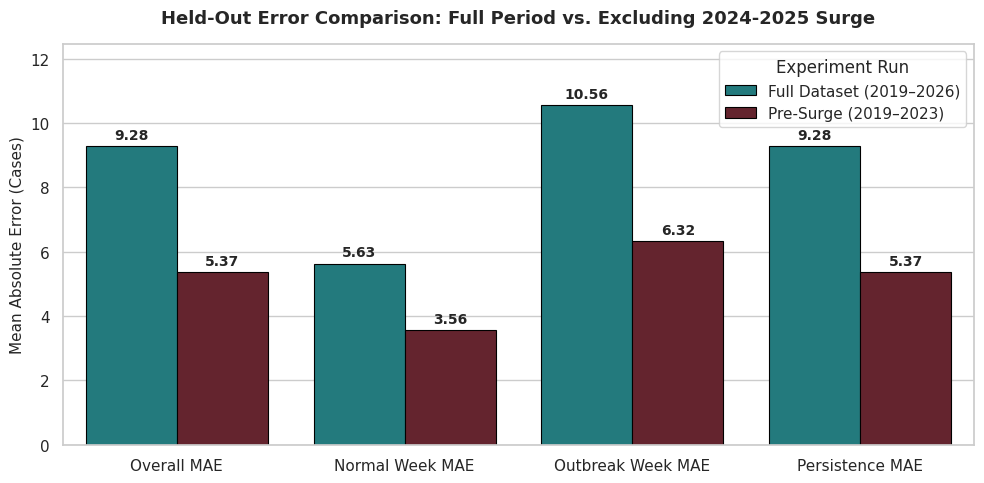

In [ ]:
# Visual of MAE comparison (Including vs. Excluding 2024)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

# Extract metrics into a DataFrame for plotting
metrics_data = []

for name, bundle in [
    ("Full Dataset (2019–2026)", full_bundle),
    ("Pre-Surge (2019–2023)", excl_bundle),
]:
    if bundle is not None:
        m = bundle.validation_metrics
        metrics_data.extend(
            [
                {
                    "Dataset": name,
                    "Metric": "Overall MAE",
                    "Value": m["mae"],
                },
                {
                    "Dataset": name,
                    "Metric": "Normal Week MAE",
                    "Value": m["normal_week_mae"],
                },
                {
                    "Dataset": name,
                    "Metric": "Outbreak Week MAE",
                    "Value": m["outbreak_week_mae"],
                },
                {
                    "Dataset": name,
                    "Metric": "Persistence MAE",
                    "Value": m["persistence_mae"],
                },
            ]
        )

df_plot = pd.DataFrame(metrics_data)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
palette = ["#14888C", "#6E1A27"]

sns.barplot(
    data=df_plot,
    x="Metric",
    y="Value",
    hue="Dataset",
    palette=palette,
    ax=ax,
    edgecolor="black",
    linewidth=0.8,
)

# Annotate bars with values
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
        )

ax.set_title(
    "Held-Out Error Comparison: Full Period vs. Excluding 2024-2025 Surge",
    fontsize=13,
    pad=15,
    fontweight="bold",
)
ax.set_ylabel("Mean Absolute Error (Cases)", fontsize=11)
ax.set_xlabel("")
ax.set_ylim(0, max(df_plot["Value"]) * 1.18)
ax.legend(title="Experiment Run", frameon=True)

plt.tight_layout()
plt.show()

***IMPLICATIONS***

[A] Including the 2024–2025 surge nearly doubles the overall MAE (5.37 $\rightarrow$ 9.28), back to MAE that is consistent with our original model.

[B] Even on normal weeks, MAE jumps from 3.56 to 5.63, showing that the higher baseline/variance during surge years elevates absolute error scale across all week types.

My guess as to why our MAE has worsened with the API is not the fact that we are using much more recent data, but that XGBoost is struggling with surge outbreak data. (I think) it may actually be better to remove surge outbreak data when building models to maintain accuracy, since the models themselves are used for preventative measures against those surges; in other words, by not accounting for the surges and performing better predictions, we account for / address the surges better.

# After Syed's 2024 Removal

In [ ]:
# Run this in a Colab cell. It will prompt a file-picker dialog --
# upload compare_full_vs_presurge.json (produced by compare_full_vs_presurge.py).

from google.colab import files
import json
import matplotlib.pyplot as plt
import numpy as np

uploaded = files.upload()  # pick compare_full_vs_presurge.json in the dialog
filename = next(iter(uploaded))
report = json.loads(uploaded[filename].decode("utf-8"))

LABELS = ["Overall MAE", "Normal Week MAE", "Outbreak Week MAE", "Persistence MAE"]
KEYS = ["overall_mae", "normal_week_mae", "outbreak_week_mae", "persistence_mae"]

full = [report["full_dataset_2019_2026"][key] for key in KEYS]
pre_surge = [report["pre_surge_2019_2023"][key] for key in KEYS]

x = np.arange(len(LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars_full = ax.bar(
    x - width / 2, full, width,
    label="Full Dataset (2019\u20132026)", color="#2a7f7f", edgecolor="black",
)
bars_pre = ax.bar(
    x + width / 2, pre_surge, width,
    label="Pre-Surge (2019\u20132023)", color="#6b1220", edgecolor="black",
)

for bars in (bars_full, bars_pre):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontweight="bold",
        )

ax.set_ylabel("Mean Absolute Error (Cases)")
ax.set_title(
    "Held-Out Error Comparison: Full Period vs. Excluding 2024-2025 Surge",
    fontsize=14, fontweight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.legend(title="Experiment Run")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

fig.tight_layout()
plt.show()

Saving compare_training_with_without_2024.py to compare_training_with_without_2024.py


JSONDecodeError: Extra data: line 1 column 3 (char 2)